# NN7 branched-attention debug lab

This notebook isolates the question:

> **Does the spatial reference branch actually affect the target face, and at which stage does the effect disappear?**

It deliberately avoids training. It reuses the repository's current:

- Hydra model and pipeline configs;
- PhotoMaker V2 ID encoder;
- clean spatial-patch extraction;
- `PackedResidualBranchedAttnProcessor`;
- target/reference masks;
- RealVis validation backbone;
- output anchor and diagnostic hooks.

The notebook uses several images from **one identity group** in `cosmic_large_neb`:

```text
PM identity image A
same-ID spatial reference A1
same-ID spatial reference A2
optional wrong-ID spatial reference B
```

The PhotoMaker identity image and prompt remain fixed. Only the spatial reference and branch authority change.

## Diagnostic ladder

1. **Patch-token test**  
   Confirms that two references produce different clean patch memories.

2. **Processor microprobe**  
   Calls one real installed BA processor directly. This proves whether reference A/B changes its target output before the rest of the U-Net.

3. **Full-pipeline matrix**
   - ordinary PhotoMaker;
   - BA active with runtime scale zero;
   - current configured BA authority;
   - same-ID reference swap;
   - deliberately strong BA positive control;
   - optional no-anchor/full-core stress test;
   - optional wrong-ID reference.

4. **Decision table**  
   Identifies whether the problem is:
   - reference extraction;
   - processor math;
   - branch authority;
   - mask/core size;
   - output anchoring;
   - full U-Net washout;
   - or validation/checkpoint propagation.

## Important

- Run this notebook on a free GPU; do not share the GPU with an active training job.
- Start with `CHECKPOINT_PATH = None` to inspect step-zero behavior.
- Restart the kernel when switching architecture configs or checkpoints. This avoids stale processor registries.
- The default config below reproduces the launcher `start_ba_NN7a_init_1gpu.sh`. Switch to `one_id_ba_NN7a_init_v2` to test the complete sibling-attention-space version.


## v3 notebook fixes

This version applies the real launcher dtype/rank overrides and explicitly moves the complete model—including the manually attached PhotoMaker ID encoder—to the accelerator device.

It also derives image-input device and dtype from the actual ID-encoder parameters, preventing CPU/GPU mismatches.


In [1]:
# ---------------------------
# USER SETTINGS
# ---------------------------
from pathlib import Path
from datetime import datetime

REPO_ROOT = Path("/home/niko/rsrch/diffusion_template")

# Exact current launcher:
CONFIG_NAME = "one_id_ba_NN7a_init"

# Revised complete sibling-attn2-space config, when desired:
# CONFIG_NAME = "one_id_ba_NN7a_init_v2"

BASE_MODEL = "SG161222/RealVisXL_V4.0"

# Match the actual training launcher overrides. The repository model YAML
# currently defaults to the unsupported string "bf32"; the launch scripts
# override it to bf16. Keep this explicit in the notebook.
MODEL_WEIGHT_DTYPE = "bf16"  # bf16 | fp16 | fp32
MODEL_LORA_RANK = 32
PHOTOMAKER_PATH = Path("/home/niko/models/PhotoMaker-V2/photomaker-v2.bin")

# None = untrained/step-zero branch.
# Example:
# CHECKPOINT_PATH = REPO_ROOT / "saved/ba_NN7a_init_1gpu/checkpoint-epoch1.pth"
CHECKPOINT_PATH = None

DATA_JSON = Path("/home/niko/datasets/gathered_data_cosmic_large_filtered.json")
FACE_IMAGE_ROOT = Path(
    "/home/niko/datasets/LAION-5B-Filtered-Large-Faces/laion1B-nolang"
)
PATH_PREFIX_TO_STRIP = "LAION-5B-Filtered-Large/laion1B-nolang"

# None selects the largest valid identity group automatically.
# After the dataset-index cell, copy a printed key here for a fixed identity.
IDENTITY_KEY = None
MIN_SAME_ID_IMAGES = 3
RUN_WRONG_ID_CONTROL = True

PROMPT = (
    "a high quality cinematic photograph of a person img, "
    "looking toward the camera, natural skin texture, detailed face"
)
NEGATIVE_PROMPT = (
    "low quality, blurry, deformed face, duplicated face, extra eyes, "
    "extra mouth, bad anatomy, illustration, painting"
)

SEED = 0
HEIGHT = 1024
WIDTH = 1024
GUIDANCE_SCALE = 5.0

# Fast mode preserves the original schedule ratios:
# PhotoMaker starts at 20%; BA starts at 30%.
FAST_MODE = True
NUM_STEPS = 20 if FAST_MODE else 50
PHOTOMAKER_START_STEP = 4 if FAST_MODE else 10
BRANCHED_START_STEP = 6 if FAST_MODE else 15

RUN_PROCESSOR_MICROPROBE = True
RUN_FULL_PIPELINE_MATRIX = True
RUN_EXTENDED_STRESS_CASES = False

TARGET_BBOX_OVERRIDE = None  # [x0, y0, x1, y1] if face detection fails.

OUTPUT_DIR = (
    REPO_ROOT
    / "debug_nn7_branch_notebook"
    / f"{datetime.now():%Y%m%d_%H%M%S}_{CONFIG_NAME}"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Config:", CONFIG_NAME)
print("Base:", BASE_MODEL)
print("Checkpoint:", CHECKPOINT_PATH)
print("Steps:", NUM_STEPS, "PM start:", PHOTOMAKER_START_STEP,
      "BA start:", BRANCHED_START_STEP)
print("Output:", OUTPUT_DIR)


Config: one_id_ba_NN7a_init
Base: SG161222/RealVisXL_V4.0
Checkpoint: None
Steps: 20 PM start: 4 BA start: 6
Output: /home/niko/rsrch/diffusion_template/debug_nn7_branch_notebook/20260722_191909_one_id_ba_NN7a_init


In [2]:
# ---------------------------
# ENVIRONMENT AND IMPORTS
# ---------------------------
import os
import sys
import gc
import json
import math
import hashlib
import random
from contextlib import contextmanager
from copy import deepcopy
from dataclasses import dataclass
from typing import Any, Callable, Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display
from matplotlib.patches import Rectangle

assert REPO_ROOT.exists(), REPO_ROOT
assert PHOTOMAKER_PATH.exists(), PHOTOMAKER_PATH
assert DATA_JSON.exists(), DATA_JSON
assert FACE_IMAGE_ROOT.exists(), FACE_IMAGE_ROOT

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ.setdefault("FACEANALYSIS_CPU", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("This notebook requires a CUDA GPU.")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA device:", torch.cuda.get_device_name(0))
print("Working directory:", Path.cwd())


Python: 3.10.18
PyTorch: 2.6.0+cu124
CUDA device: NVIDIA H100 80GB HBM3
Working directory: /home/niko/rsrch/diffusion_template


## 1. Select several images from one dataset identity

The dataset JSON has changed format over time. The helper below accepts both common layouts:

```text
A. parent-image record
{
  "<identity-or-parent-key>": {
    "face_paths": [...],
    "face_bboxes": {...}
  }
}
```

and:

```text
B. nested identity record
{
  "<identity>": {
    "<image_id>": {
      "new_face_crop": [...]
    }
  }
}
```

It verifies that image files and bboxes are valid before selecting a group.


In [3]:
# ---------------------------
# DATASET INDEXING
# ---------------------------
@dataclass(frozen=True)
class RefItem:
    identity: str
    raw_path: str
    path: Path
    bbox: tuple[float, float, float, float]

    def open(self) -> Image.Image:
        return Image.open(self.path).convert("RGB")


def valid_bbox(value: Any) -> bool:
    if not isinstance(value, (list, tuple)) or len(value) != 4:
        return False
    try:
        x0, y0, x1, y1 = (float(v) for v in value)
    except (TypeError, ValueError):
        return False
    return (
        all(math.isfinite(v) for v in (x0, y0, x1, y1))
        and x1 > x0
        and y1 > y0
        and x0 >= 0
        and y0 >= 0
    )


def resolve_face_path(raw_path: str) -> Path:
    raw = str(raw_path).replace("\\", "/")
    raw_path_obj = Path(raw)

    candidates: list[Path] = []
    if raw_path_obj.is_absolute():
        candidates.append(raw_path_obj)

    stripped = raw.lstrip("/")
    prefix = PATH_PREFIX_TO_STRIP.strip("/")
    if prefix and stripped.startswith(prefix + "/"):
        stripped = stripped[len(prefix) + 1 :]

    root_name = FACE_IMAGE_ROOT.name
    marker = f"/{root_name}/"
    marked = "/" + raw.lstrip("/")
    if marker in marked:
        stripped = marked.split(marker, 1)[1]

    candidates.extend(
        [
            FACE_IMAGE_ROOT / stripped,
            FACE_IMAGE_ROOT / raw.lstrip("/"),
            DATA_JSON.parent / stripped,
            Path("/home/niko/datasets") / stripped,
        ]
    )

    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return candidate

    # Return the most likely path so the caller can report it.
    return FACE_IMAGE_ROOT / stripped


def lookup_bbox(record: dict, raw_path: str) -> Optional[list[float]]:
    bbox_map = record.get("face_bboxes") or {}
    raw = str(raw_path).replace("\\", "/")
    stripped = raw.lstrip("/")
    prefix = PATH_PREFIX_TO_STRIP.strip("/")
    prefix_stripped = (
        stripped[len(prefix) + 1 :]
        if prefix and stripped.startswith(prefix + "/")
        else stripped
    )
    candidates = [
        raw,
        stripped,
        prefix_stripped,
        str(Path(raw)),
        str(Path(stripped)),
        str(Path(prefix_stripped)),
    ]
    for key in candidates:
        bbox = bbox_map.get(key)
        if valid_bbox(bbox):
            return [float(v) for v in bbox]

    for field in ("new_face_crop", "face_crop_new", "face_crop"):
        bbox = record.get(field)
        if valid_bbox(bbox):
            return [float(v) for v in bbox]
    return None


def build_identity_groups(data: dict) -> dict[str, list[RefItem]]:
    groups: dict[str, list[RefItem]] = {}

    for identity, record in data.items():
        if not isinstance(record, dict):
            continue

        items: list[RefItem] = []
        face_paths = record.get("face_paths")
        if isinstance(face_paths, list):
            for raw_path in face_paths:
                bbox = lookup_bbox(record, str(raw_path))
                path = resolve_face_path(str(raw_path))
                if bbox is None or not path.exists():
                    continue
                items.append(
                    RefItem(
                        identity=str(identity),
                        raw_path=str(raw_path),
                        path=path,
                        bbox=tuple(bbox),
                    )
                )
        else:
            # Nested identity → image-record format.
            for image_id, image_record in record.items():
                if not isinstance(image_record, dict):
                    continue
                raw_path = (
                    image_record.get("path")
                    or image_record.get("image_path")
                    or f"{identity}/{image_id}.jpg"
                )
                bbox = None
                for field in ("new_face_crop", "face_crop_new", "face_crop"):
                    if valid_bbox(image_record.get(field)):
                        bbox = [float(v) for v in image_record[field]]
                        break
                path = resolve_face_path(str(raw_path))
                if bbox is None or not path.exists():
                    continue
                items.append(
                    RefItem(
                        identity=str(identity),
                        raw_path=str(raw_path),
                        path=path,
                        bbox=tuple(bbox),
                    )
                )

        # Deduplicate paths while preserving order.
        unique: list[RefItem] = []
        seen: set[Path] = set()
        for item in items:
            resolved = item.path.resolve()
            if resolved not in seen:
                seen.add(resolved)
                unique.append(item)
        if unique:
            groups[str(identity)] = unique

    return groups


with DATA_JSON.open("r") as handle:
    dataset_json = json.load(handle)

identity_groups = build_identity_groups(dataset_json)
eligible = {
    key: values
    for key, values in identity_groups.items()
    if len(values) >= MIN_SAME_ID_IMAGES
}
if not eligible:
    raise RuntimeError(
        "No identity group with enough valid image files was found. "
        "Check DATA_JSON, FACE_IMAGE_ROOT and PATH_PREFIX_TO_STRIP."
    )

ranked = sorted(eligible.items(), key=lambda pair: len(pair[1]), reverse=True)
print("Eligible identity groups:", len(ranked))
print("Largest groups:")
for key, values in ranked[:10]:
    print(f"  {len(values):3d}  {key}")

if IDENTITY_KEY is None:
    selected_identity, selected_items = ranked[0]
else:
    if IDENTITY_KEY not in eligible:
        raise KeyError(
            f"IDENTITY_KEY={IDENTITY_KEY!r} is unavailable or has fewer than "
            f"{MIN_SAME_ID_IMAGES} valid images."
        )
    selected_identity = IDENTITY_KEY
    selected_items = eligible[selected_identity]

pm_item = selected_items[0]
spatial_item_a = selected_items[1]
spatial_item_b = selected_items[2]

wrong_item = None
if RUN_WRONG_ID_CONTROL:
    for key, values in ranked:
        if key != selected_identity and values:
            wrong_item = values[0]
            break

print("\nSelected identity:", selected_identity)
for label, item in (
    ("PM identity", pm_item),
    ("spatial A", spatial_item_a),
    ("spatial B same ID", spatial_item_b),
    ("wrong ID", wrong_item),
):
    if item is not None:
        print(f"  {label:20s}: {item.path}  bbox={item.bbox}")


Eligible identity groups: 59143
Largest groups:
   10  LAION-5B-Filtered-Large/laion1B-nolang/00108/2610585006997.jpg
   10  LAION-5B-Filtered-Large/laion1B-nolang/00108/3723348021667.jpg
   10  LAION-5B-Filtered-Large/laion1B-nolang/00108/2696338009646.jpg
   10  LAION-5B-Filtered-Large/laion1B-nolang/00108/3316999011113.jpg
   10  LAION-5B-Filtered-Large/laion1B-nolang/00108/1118399003694.jpg
   10  LAION-5B-Filtered-Large/laion1B-nolang/00108/4275752024380.webp
   10  LAION-5B-Filtered-Large/laion1B-nolang/00108/3616160023167.jpg
   10  LAION-5B-Filtered-Large/laion1B-nolang/00108/3315401036060.jpg
   10  LAION-5B-Filtered-Large/laion1B-nolang/00108/1115147002550.webp
   10  LAION-5B-Filtered-Large/laion1B-nolang/00108/1210237008183.webp

Selected identity: LAION-5B-Filtered-Large/laion1B-nolang/00108/2610585006997.jpg
  PM identity         : /home/niko/datasets/LAION-5B-Filtered-Large-Faces/laion1B-nolang/00108/2610585006997_jpg/2.jpg  bbox=(56.0, 47.0, 197.0, 230.0)
  spatial A   

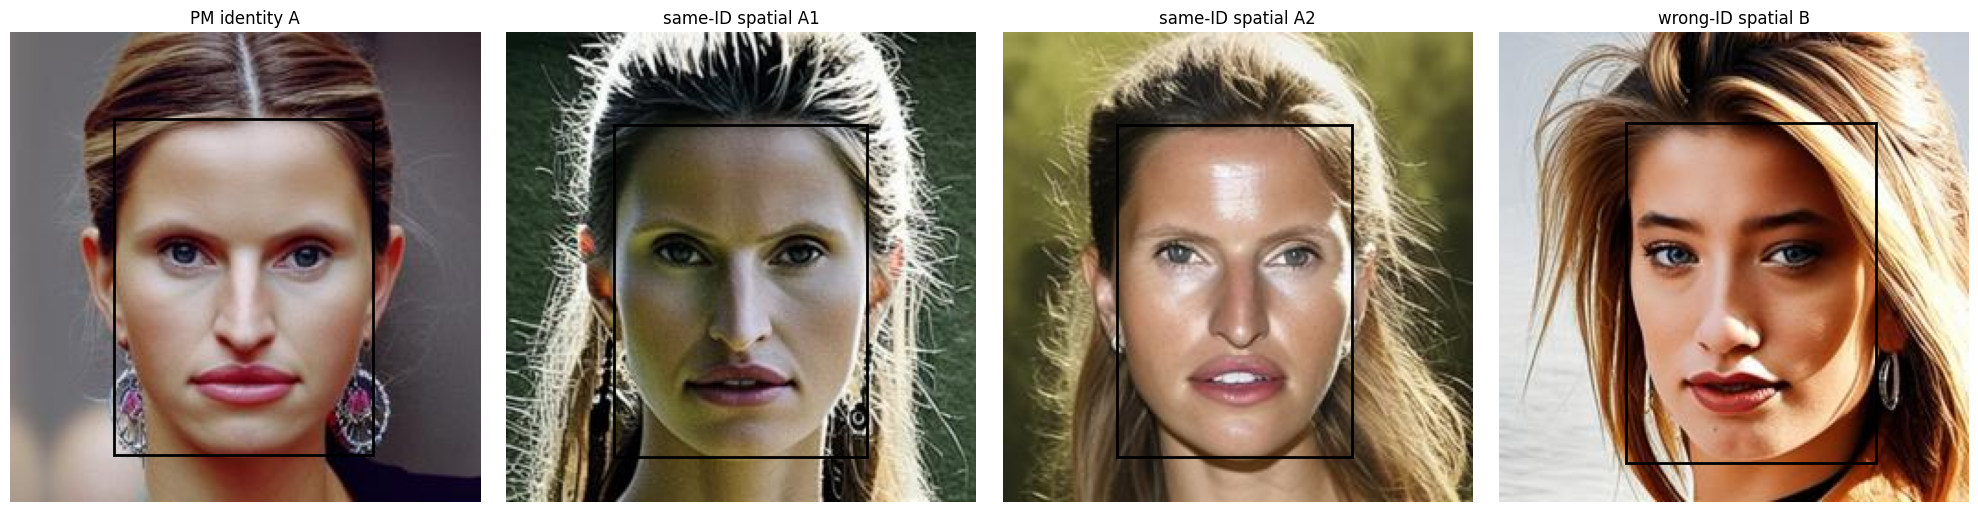

In [4]:
# ---------------------------
# VISUALIZE SELECTED REFERENCES
# ---------------------------
def show_item(ax, item: RefItem, title: str) -> None:
    image = item.open()
    ax.imshow(image)
    x0, y0, x1, y1 = item.bbox
    ax.add_patch(
        Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            fill=False,
            linewidth=2,
        )
    )
    ax.set_title(title)
    ax.axis("off")


items_to_show = [
    ("PM identity A", pm_item),
    ("same-ID spatial A1", spatial_item_a),
    ("same-ID spatial A2", spatial_item_b),
]
if wrong_item is not None:
    items_to_show.append(("wrong-ID spatial B", wrong_item))

fig, axes = plt.subplots(1, len(items_to_show), figsize=(5 * len(items_to_show), 5))
if len(items_to_show) == 1:
    axes = [axes]
for axis, (title, item) in zip(axes, items_to_show):
    show_item(axis, item, title)
plt.tight_layout()
plt.show()


## 2. Build the exact project model and pipeline

The helper:

1. composes the selected repository Hydra config;
2. overrides both model and pipeline to the chosen debug backbone;
3. installs branched processors through `prepare_for_training()`;
4. optionally loads a training checkpoint;
5. creates the project `PhotomakerBranchedPipeline`;
6. prints the active BA architecture and processor authority.

No optimizer or training loop is created.


In [10]:
# ---------------------------
# MODEL / PIPELINE CONSTRUCTION
# ---------------------------
from accelerate import Accelerator
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate
from omegaconf import OmegaConf, open_dict

from src.model.photomaker_branched.packed_residual_attn_processor import (
    PackedResidualBranchedAttnProcessor,
    make_inner_core_mask,
)


def compose_debug_config(config_name: str):
    GlobalHydra.instance().clear()
    with initialize_config_dir(
        version_base=None,
        config_dir=str(REPO_ROOT / "src/configs"),
    ):
        cfg = compose(config_name=config_name)

    with open_dict(cfg):
        cfg.model.pretrained_model_name_or_path = BASE_MODEL
        cfg.pipeline.pretrained_model_name_or_path = BASE_MODEL
        cfg.model.photomaker_path = str(PHOTOMAKER_PATH)

        # Reproduce the real launcher overrides. Without this, the repository
        # model YAML supplies "bf32", which SDXL.__init__ does not recognize and
        # therefore never creates model.weight_dtype.
        cfg.model.weight_dtype = MODEL_WEIGHT_DTYPE
        cfg.model.rank = int(MODEL_LORA_RANK)
        cfg.pretrained_model_for_validation_name_or_path = None
        cfg.update_proc_weights_val = True
        if "variant" in cfg.pipeline:
            cfg.pipeline.variant = None

    OmegaConf.resolve(cfg)
    return cfg


def load_project_checkpoint(model, checkpoint_path: Optional[Path]) -> int:
    if checkpoint_path is None:
        return 0
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(checkpoint_path)

    payload = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )
    state = payload.get("state_dict", payload)
    model.load_state_dict_(state)
    return int(payload.get("epoch", 0)) if isinstance(payload, dict) else 0


def ba_runtime_kwargs(cfg) -> dict[str, Any]:
    keys = (
        "train_ba_only",
        "ba_train_top_k",
        "ba_patch_top_k",
        "non_ba_train",
        "train_ba_all_steps",
        "ba_weights_split",
        "use_attn_v2",
    )
    return {
        key: getattr(cfg, key)
        for key in keys
        if hasattr(cfg, key)
    }

def devices_match(left, right):
    """Treat `cuda` and `cuda:<current index>` as the same device."""
    left = torch.device(left)
    right = torch.device(right)

    if left.type != right.type:
        return False

    if left.type != "cuda":
        return left == right

    left_index = (
        torch.cuda.current_device()
        if left.index is None
        else left.index
    )
    right_index = (
        torch.cuda.current_device()
        if right.index is None
        else right.index
    )
    return left_index == right_index




def build_debug_model_and_pipeline(config_name: str):
    cfg = compose_debug_config(config_name)
    accelerator = Accelerator()
    device = accelerator.device

    model = instantiate(
        cfg.model,
        device=device,
        **ba_runtime_kwargs(cfg),
    )
    model.disable_branched_sa = bool(
        getattr(cfg, "disable_branched_sa", False)
    )
    model.disable_branched_ca = bool(
        getattr(cfg, "disable_branched_ca", False)
    )
    model.strict_face_routing = bool(
        getattr(cfg, "strict_face_routing", False)
    )

    if not hasattr(model, "weight_dtype"):
        raise RuntimeError(
            "Model construction did not create weight_dtype. "
            f"Configured cfg.model.weight_dtype={cfg.model.weight_dtype!r}. "
            "Use one of: bf16, fp16, fp32."
        )
    print(
        "Model construction:",
        f"configured_dtype={cfg.model.weight_dtype}",
        f"torch_dtype={model.weight_dtype}",
        f"rank={cfg.model.rank}",
    )

    model.prepare_for_training()
    loaded_epoch = load_project_checkpoint(model, CHECKPOINT_PATH)
    model.eval()

    # The project pipeline attaches id_encoder manually rather than registering
    # it as a standard DiffusionPipeline component. Move the full model before
    # building the pipeline so UNet, VAE, text encoders, processors, and the
    # PhotoMaker ID encoder all live on the same accelerator device.
    model.to(device)

    pipe = instantiate(
        cfg.pipeline,
        model=model,
        accelerator=accelerator,
    )
    pipe.disable_branched_sa = model.disable_branched_sa
    pipe.disable_branched_ca = model.disable_branched_ca
    pipe.strict_face_routing = model.strict_face_routing
    pipe.to(device)

    # DiffusionPipeline.to() does not necessarily traverse manually attached
    # modules. Keep this explicit and fail early if placement is inconsistent.
    pipe.id_encoder.to(device=device, dtype=model.weight_dtype)

    unet_device = next(pipe.unet.parameters()).device
    id_encoder_parameter = next(pipe.id_encoder.parameters())
    id_encoder_device = id_encoder_parameter.device
    id_encoder_dtype = id_encoder_parameter.dtype

    if not devices_match(unet_device, device):
        raise RuntimeError(
            f"UNet is on {unet_device}, expected accelerator device {device}"
        )

    if not devices_match(id_encoder_device, device):
        raise RuntimeError(
            f"PhotoMaker ID encoder is on {id_encoder_device}, "
            f"expected accelerator device {device}"
        )


    print(
        "Runtime placement:",
        f"unet={unet_device}/{pipe.unet.dtype}",
        f"id_encoder={id_encoder_device}/{id_encoder_dtype}",
    )

    pipe.set_progress_bar_config(disable=False)
    pipe._runtime_uses_branched_unet = None

    return cfg, accelerator, model, pipe, loaded_epoch


cfg, accelerator, model, pipe, loaded_epoch = build_debug_model_and_pipeline(
    CONFIG_NAME
)
device = accelerator.device

print("\nLoaded epoch:", loaded_epoch)
print("Device:", device)
print("Pipeline base:", BASE_MODEL)


You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


Model construction: configured_dtype=bf16 torch_dtype=torch.bfloat16 rank=32


/home/niko/miniconda3/envs/photomaker_NS/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


[NN7a_init warm start] site=up_blocks.1.attentions.0.transformer_blocks.0.attn1.processor patch_projection=pmv2_perceiver_context patch_dim=2048 kv_init=sibling_attn2 kv_kind=lora attention_space=attn1_hybrid gate_position=post_cap q_base_parity=na k_base_parity=true v_base_parity=true out_base_parity=na effective_gate_init=0.050000
[NN7a_init warm start] site=up_blocks.1.attentions.0.transformer_blocks.1.attn1.processor patch_projection=pmv2_perceiver_context patch_dim=2048 kv_init=sibling_attn2 kv_kind=lora attention_space=attn1_hybrid gate_position=post_cap q_base_parity=na k_base_parity=true v_base_parity=true out_base_parity=na effective_gate_init=0.050000
[NN7a_init warm start] site=up_blocks.1.attentions.1.transformer_blocks.0.attn1.processor patch_projection=pmv2_perceiver_context patch_dim=2048 kv_init=sibling_attn2 kv_kind=lora attention_space=attn1_hybrid gate_position=post_cap q_base_parity=na k_base_parity=true v_base_parity=true out_base_parity=na effective_gate_init=0.05

Keyword arguments {'train_branch_mode': 'both', 'auto_mask_ref': False, 'use_dynamic_mask': False, 'use_bbox_mask_ref': True, 'use_bbox_mask_gen': True} are not expected by PhotoMakerStableDiffusionXLPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 11744.05it/s]


Runtime placement: unet=cuda:0/torch.bfloat16 id_encoder=cuda:0/torch.bfloat16

Loaded epoch: 0
Device: cuda
Pipeline base: SG161222/RealVisXL_V4.0


In [11]:
# ---------------------------
# VERIFY ACTIVE PROCESSORS AND AUTHORITY
# ---------------------------
def branched_registry(pipeline) -> dict[str, Any]:
    registry = getattr(pipeline, "_branched_attn_processors", None)
    if isinstance(registry, dict):
        return registry
    return dict(pipeline.unet.attn_processors)


def packed_processor_items(pipeline):
    return [
        (name, processor)
        for name, processor in branched_registry(pipeline).items()
        if isinstance(processor, PackedResidualBranchedAttnProcessor)
    ]


def effective_spatial_gate(processor) -> float:
    return float(
        processor.spatial_gate_max
        * torch.sigmoid(processor.gate_logit.detach().float()).item()
    )


processor_items = packed_processor_items(pipe)
if not processor_items:
    raise RuntimeError("No PackedResidualBranchedAttnProcessor was installed.")

processor_rows = []
for name, processor in processor_items:
    trainable = [
        key
        for key, parameter in processor.named_parameters()
        if parameter.requires_grad
    ]
    processor_rows.append(
        {
            "processor": name,
            "identity_mode": processor.identity_fusion_mode,
            "spatial_enabled": processor.enable_spatial,
            "patch_projection": getattr(
                processor, "spatial_patch_projection", None
            ),
            "patch_dim": processor.spatial_patch_dim,
            "kv_init": getattr(processor, "spatial_kv_init", None),
            "kv_kind": getattr(processor, "spatial_kv_kind", None),
            "attention_space": getattr(
                processor, "spatial_attention_space", "attn1_hybrid"
            ),
            "gate_position": getattr(
                processor, "spatial_gate_position", "post_cap"
            ),
            "effective_gate": effective_spatial_gate(processor),
            "spatial_cap": processor.spatial_delta_rms_cap,
            "total_cap": processor.total_delta_rms_cap,
            "local_window": processor.spatial_local_window,
            "trainable_keys": ", ".join(trainable),
        }
    )

processor_df = pd.DataFrame(processor_rows)
display(processor_df)

print("Active pipeline fields:")
for key in (
    "ba_spatial_patch_projection",
    "ba_spatial_patch_dim",
    "ba_spatial_kv_init",
    "ba_spatial_kv_kind",
    "ba_spatial_attention_space",
    "ba_spatial_gate_position",
    "ba_spatial_gate_max",
    "ba_gate_init_logit",
    "ba_spatial_delta_rms_cap",
    "ba_total_delta_rms_cap",
    "ba_target_core_erode_frac",
    "ba_output_anchor_mode",
):
    print(f"  {key:36s} = {getattr(pipe, key, '<missing>')}")

print("\nSelected BA sites:", len(processor_items))
print("First site:", processor_items[0][0])


,processor,identity_mode,spatial_enabled,patch_projection,patch_dim,kv_init,kv_kind,attention_space,gate_position,effective_gate,spatial_cap,total_cap,local_window,trainable_keys
0,up_blocks.1.attentions.0.transformer_blocks.0....,factorized_dual,True,pmv2_perceiver_context,2048,sibling_attn2,lora,attn1_hybrid,post_cap,0.050231,0.45,0.45,5,"gate_logit, ref_to_k.lora_A, ref_to_k.lora_B, ..."
1,up_blocks.1.attentions.0.transformer_blocks.1....,factorized_dual,True,pmv2_perceiver_context,2048,sibling_attn2,lora,attn1_hybrid,post_cap,0.050231,0.45,0.45,5,"gate_logit, ref_to_k.lora_A, ref_to_k.lora_B, ..."
2,up_blocks.1.attentions.1.transformer_blocks.0....,factorized_dual,True,pmv2_perceiver_context,2048,sibling_attn2,lora,attn1_hybrid,post_cap,0.050231,0.45,0.45,5,"gate_logit, ref_to_k.lora_A, ref_to_k.lora_B, ..."
3,up_blocks.1.attentions.1.transformer_blocks.1....,factorized_dual,True,pmv2_perceiver_context,2048,sibling_attn2,lora,attn1_hybrid,post_cap,0.050231,0.45,0.45,5,"gate_logit, ref_to_k.lora_A, ref_to_k.lora_B, ..."
4,up_blocks.1.attentions.2.transformer_blocks.0....,factorized_dual,True,pmv2_perceiver_context,2048,sibling_attn2,lora,attn1_hybrid,post_cap,0.050231,0.45,0.45,5,"gate_logit, ref_to_k.lora_A, ref_to_k.lora_B, ..."
5,up_blocks.1.attentions.2.transformer_blocks.1....,factorized_dual,True,pmv2_perceiver_context,2048,sibling_attn2,lora,attn1_hybrid,post_cap,0.050231,0.45,0.45,5,"gate_logit, ref_to_k.lora_A, ref_to_k.lora_B, ..."


Active pipeline fields:
  ba_spatial_patch_projection          = pmv2_perceiver_context
  ba_spatial_patch_dim                 = 2048
  ba_spatial_kv_init                   = sibling_attn2
  ba_spatial_kv_kind                   = lora
  ba_spatial_attention_space           = attn1_hybrid
  ba_spatial_gate_position             = post_cap
  ba_spatial_gate_max                  = 0.8
  ba_gate_init_logit                   = -2.70805020110221
  ba_spatial_delta_rms_cap             = 0.45
  ba_total_delta_rms_cap               = 0.45
  ba_target_core_erode_frac            = 0.15
  ba_output_anchor_mode                = base_outside_core

Selected BA sites: 6
First site: up_blocks.1.attentions.0.transformer_blocks.0.attn1.processor


## 3. Verify clean patch memories

If same-ID reference images produce byte-identical patch memories, the branch cannot distinguish them.

Expected:

```text
hash(A1) != hash(A2)
RMS(A1 - A2) > 0
cosine(A1, A2) < 1
```

A high cosine is normal for the same identity. Exact equality is not.


In [12]:
# Confirm all manually attached modules are on compatible devices.
placement_rows = []
for module_name, module in (
    ('unet', pipe.unet),
    ('vae', pipe.vae),
    ('id_encoder', pipe.id_encoder),
):
    parameter = next(module.parameters())
    placement_rows.append(
        {
            'module': module_name,
            'device': str(parameter.device),
            'dtype': str(parameter.dtype),
        }
    )
display(pd.DataFrame(placement_rows))

devices = {row['device'] for row in placement_rows}
if len(devices) != 1:
    raise RuntimeError(f'Model modules span multiple devices: {devices}')


,module,device,dtype
0,unet,cuda:0,torch.bfloat16
1,vae,cuda:0,torch.bfloat16
2,id_encoder,cuda:0,torch.bfloat16


In [13]:
# ---------------------------
# EXTRACT ACTUAL REFERENCE PATCH TOKENS
# ---------------------------
def crop_face(item: RefItem) -> Image.Image:
    image = item.open()
    x0, y0, x1, y1 = item.bbox
    box = (
        max(0, int(math.floor(x0))),
        max(0, int(math.floor(y0))),
        min(image.width, int(math.ceil(x1))),
        min(image.height, int(math.ceil(y1))),
    )
    if box[2] <= box[0] or box[3] <= box[1]:
        raise ValueError(f"Empty bbox after clamping: {item}")
    return image.crop(box)


@torch.inference_mode()
def extract_patch_tokens(item: RefItem) -> torch.Tensor:
    crop = crop_face(item)
    pixels = pipe.id_image_processor(
        [crop],
        return_tensors="pt",
    ).pixel_values.unsqueeze(1)

    encoder_parameter = next(pipe.id_encoder.parameters())
    encoder_device = encoder_parameter.device
    encoder_dtype = encoder_parameter.dtype
    unet_parameter = next(pipe.unet.parameters())

    pixels = pixels.to(
        device=encoder_device,
        dtype=encoder_dtype,
    )

    tokens = pipe.id_encoder.extract_spatial_patch_tokens(
        pixels,
        projection=pipe.ba_spatial_patch_projection,
    )
    tokens = tokens.to(
        device=unet_parameter.device,
        dtype=unet_parameter.dtype,
    )
    if tokens.shape[-1] != int(pipe.ba_spatial_patch_dim):
        raise RuntimeError(
            f"Patch dim {tokens.shape[-1]} != config "
            f"{pipe.ba_spatial_patch_dim}"
        )
    return tokens


def tensor_hash(tensor: torch.Tensor) -> str:
    raw = (
        tensor.detach()
        .contiguous()
        .cpu()
        .view(torch.uint8)
        .numpy()
        .tobytes()
    )
    return hashlib.sha256(raw).hexdigest()


patch_a = extract_patch_tokens(spatial_item_a)
patch_b = extract_patch_tokens(spatial_item_b)
patch_wrong = (
    extract_patch_tokens(wrong_item)
    if wrong_item is not None
    else None
)

def patch_comparison(left, right) -> dict[str, float]:
    left_f = left.float().flatten(1)
    right_f = right.float().flatten(1)
    return {
        "rms_left": float(left_f.square().mean().sqrt().item()),
        "rms_right": float(right_f.square().mean().sqrt().item()),
        "rms_difference": float(
            (left_f - right_f).square().mean().sqrt().item()
        ),
        "mean_abs_difference": float(
            (left_f - right_f).abs().mean().item()
        ),
        "cosine": float(
            torch.nn.functional.cosine_similarity(
                left_f,
                right_f,
                dim=1,
            ).mean().item()
        ),
    }

print("A shape:", tuple(patch_a.shape), "hash:", tensor_hash(patch_a))
print("B shape:", tuple(patch_b.shape), "hash:", tensor_hash(patch_b))
display(pd.DataFrame([{"pair": "same-ID A1/A2", **patch_comparison(patch_a, patch_b)}]))

if patch_wrong is not None:
    print("Wrong-ID hash:", tensor_hash(patch_wrong))
    display(
        pd.DataFrame(
            [
                {
                    "pair": "same-ID A1 / wrong-ID B",
                    **patch_comparison(patch_a, patch_wrong),
                }
            ]
        )
    )

if torch.equal(patch_a, patch_b):
    raise RuntimeError(
        "Same-ID reference A/B patch tokens are byte-identical. "
        "Debug reference selection or token extraction before running the U-Net."
    )


A shape: (1, 256, 2048) hash: 16736eb3e46d3f7f226d47019fe3e41a5f7e4d64e7150552615eb72cd18c1ca8
B shape: (1, 256, 2048) hash: fc95c0a63cda6d19850f560a9e0b6735ad330f05fb5a50f8f9463d91c5d09683


,pair,rms_left,rms_right,rms_difference,mean_abs_difference,cosine
0,same-ID A1/A2,0.452313,0.453385,0.441139,0.346334,0.525527


Wrong-ID hash: d89c8ecf67fb7b471d930222fdd7108005ba2428b59ca4a108c4b59eb822c33d


,pair,rms_left,rms_right,rms_difference,mean_abs_difference,cosine
0,same-ID A1 / wrong-ID B,0.452313,0.454647,0.436483,0.342235,0.536789


## 4. Fast processor microprobe

This calls one real installed processor directly using:

- actual model attention weights;
- actual extracted reference patch memories;
- one fixed synthetic target hidden state;
- one fixed target/reference mask.

It does **not** run diffusion.

Interpretation:

- If A1/A2 differ here at strong authority, processor math and reference extraction work.
- If the full pipeline later remains unchanged, the effect is lost in scheduling, output routing, masking, or downstream U-Net computation.
- If A1/A2 do not differ even here at high authority, debug the processor before running full generations.


In [14]:
# ---------------------------
# PROCESSOR-LEVEL MICROPROBE
# ---------------------------
def resolve_attention_module(unet, processor_name: str):
    module = unet
    module_path = processor_name.rsplit(".processor", 1)[0]
    for part in module_path.split("."):
        module = module[int(part)] if part.isdigit() else getattr(module, part)
    return module


def alpha_to_logit(alpha: float, maximum: float) -> float:
    if not 0.0 < alpha < maximum:
        raise ValueError(f"Need 0 < alpha < {maximum}, got {alpha}")
    probability = alpha / maximum
    return math.log(probability / (1.0 - probability))


@contextmanager
def temporary_processor_authority(
    processors,
    *,
    alpha: Optional[float] = None,
    runtime_scale: Optional[float] = None,
    spatial_cap: Optional[float] = None,
    total_cap: Optional[float] = None,
    local_window: Optional[int] = None,
    gate_max_override: Optional[float] = None,
):
    snapshots = []
    try:
        for processor in processors:
            snapshots.append(
                {
                    "processor": processor,
                    "gate_logit": processor.gate_logit.detach().clone(),
                    "spatial_gate_max": processor.spatial_gate_max,
                    "runtime_scale": processor.runtime_scale,
                    "spatial_cap": processor.spatial_delta_rms_cap,
                    "total_cap": processor.total_delta_rms_cap,
                    "local_window": processor.spatial_local_window,
                    "patches": processor.spatial_patch_tokens,
                }
            )
            if gate_max_override is not None:
                processor.spatial_gate_max = float(gate_max_override)
            if alpha is not None:
                processor.gate_logit.data.fill_(
                    alpha_to_logit(alpha, processor.spatial_gate_max)
                )
            if runtime_scale is not None:
                processor.runtime_scale = float(runtime_scale)
            if spatial_cap is not None:
                processor.spatial_delta_rms_cap = float(spatial_cap)
            if total_cap is not None:
                processor.total_delta_rms_cap = float(total_cap)
            if local_window is not None:
                if local_window <= 0 or local_window % 2 == 0:
                    raise ValueError("local_window must be positive and odd")
                processor.spatial_local_window = int(local_window)
        yield
    finally:
        for snapshot in snapshots:
            processor = snapshot["processor"]
            processor.gate_logit.data.copy_(snapshot["gate_logit"])
            processor.spatial_gate_max = snapshot["spatial_gate_max"]
            processor.runtime_scale = snapshot["runtime_scale"]
            processor.spatial_delta_rms_cap = snapshot["spatial_cap"]
            processor.total_delta_rms_cap = snapshot["total_cap"]
            processor.spatial_local_window = snapshot["local_window"]
            processor.spatial_patch_tokens = snapshot["patches"]


def masked_rms(tensor: torch.Tensor, mask_tokens: torch.Tensor) -> float:
    mask = mask_tokens.to(dtype=tensor.dtype)
    count = (mask.sum() * tensor.shape[-1]).clamp_min(1)
    return float(
        torch.sqrt((tensor.float().square() * mask.float()).sum() / count).item()
    )


def run_processor_microprobe():
    processor_name, processor = processor_items[0]
    attention = resolve_attention_module(model.unet, processor_name)

    side = 16
    generator = torch.Generator(device=device)
    generator.manual_seed(123456)
    target_hidden = torch.randn(
        1,
        side * side,
        processor.hidden_size,
        generator=generator,
        device=device,
        dtype=model.unet.dtype,
    )
    reference_hidden = torch.randn(
        target_hidden.shape,
        generator=generator,
        device=device,
        dtype=model.unet.dtype,
    )
    doubled_hidden = torch.cat([target_hidden, reference_hidden], dim=0)

    mask = torch.zeros(
        1,
        1,
        side,
        side,
        device=device,
        dtype=model.unet.dtype,
    )
    mask[:, :, 2:-2, 2:-2] = 1
    core = make_inner_core_mask(mask, erode_frac=0.15).to(
        device=device,
        dtype=model.unet.dtype,
    )
    processor.set_masks(mask, mask, core)
    core_tokens = core.flatten(2).transpose(1, 2)
    outside_tokens = (core_tokens == 0).to(core_tokens.dtype)

    current_alpha = effective_spatial_gate(processor)
    alphas = []
    for value in (current_alpha, 0.10, 0.25, 0.50):
        if 0 < value < processor.spatial_gate_max and all(
            abs(value - existing) > 1e-8 for existing in alphas
        ):
            alphas.append(value)

    processors = [processor]
    with temporary_processor_authority(
        processors,
        runtime_scale=0.0,
    ):
        processor.spatial_patch_tokens = patch_a
        with torch.inference_mode():
            branch_off = processor(attention, doubled_hidden)[:1].float()

    outputs = {}
    rows = []
    for alpha in alphas:
        for ref_name, patches in (
            ("same_id_A1", patch_a),
            ("same_id_A2", patch_b),
        ):
            with temporary_processor_authority(
                processors,
                alpha=alpha,
                runtime_scale=1.0,
                spatial_cap=1.0,
                total_cap=1.0,
            ):
                processor.spatial_patch_tokens = patches
                with torch.inference_mode():
                    output = processor(attention, doubled_hidden)[:1].float()
                outputs[(alpha, ref_name)] = output

            delta = output - branch_off
            rows.append(
                {
                    "alpha": alpha,
                    "reference": ref_name,
                    "inside_delta_vs_off_rms": masked_rms(
                        delta, core_tokens
                    ),
                    "outside_delta_vs_off_rms": masked_rms(
                        delta, outside_tokens
                    ),
                    "outside_max_abs": float(
                        (delta * outside_tokens).abs().max().item()
                    ),
                }
            )

    for alpha in alphas:
        delta_ab = (
            outputs[(alpha, "same_id_A2")]
            - outputs[(alpha, "same_id_A1")]
        )
        rows.append(
            {
                "alpha": alpha,
                "reference": "A2_minus_A1",
                "inside_delta_vs_off_rms": masked_rms(
                    delta_ab, core_tokens
                ),
                "outside_delta_vs_off_rms": masked_rms(
                    delta_ab, outside_tokens
                ),
                "outside_max_abs": float(
                    (delta_ab * outside_tokens).abs().max().item()
                ),
            }
        )

    # Deliberate positive control.
    with temporary_processor_authority(
        processors,
        alpha=0.80,
        gate_max_override=1.0,
        runtime_scale=1.0,
        spatial_cap=1.0,
        total_cap=1.0,
        local_window=15,
    ):
        processor.spatial_patch_tokens = patch_b
        with torch.inference_mode():
            stress_output = processor(attention, doubled_hidden)[:1].float()

    stress_delta = stress_output - branch_off
    rows.append(
        {
            "alpha": 0.80,
            "reference": "A2_stress_positive_control",
            "inside_delta_vs_off_rms": masked_rms(
                stress_delta, core_tokens
            ),
            "outside_delta_vs_off_rms": masked_rms(
                stress_delta, outside_tokens
            ),
            "outside_max_abs": float(
                (stress_delta * outside_tokens).abs().max().item()
            ),
        }
    )

    return pd.DataFrame(rows)


if RUN_PROCESSOR_MICROPROBE:
    microprobe_df = run_processor_microprobe()
    display(microprobe_df)

    reference_rows = microprobe_df[
        microprobe_df["reference"] == "A2_minus_A1"
    ]
    if float(reference_rows["inside_delta_vs_off_rms"].max()) == 0.0:
        raise RuntimeError(
            "Processor microprobe found no A1/A2 reference sensitivity. "
            "Do not run the full matrix until this is fixed."
        )
else:
    print("Processor microprobe disabled.")


[BA PPR diagnostics] site=up_blocks.1.attentions.0.transformer_blocks.0.attn1.processor calls=1 roi=25/25/25 padding=0.000 gate=0.0503 pre=1.8289/1.8289 post=0.4500/0.4500 capped=1.000
[NN7a_init first batch] site=up_blocks.1.attentions.0.transformer_blocks.0.attn1.processor candidate_rms_min=0.252663 applied_rms_min=0.006360 candidate_ratio_min=1.828870 candidate_ratio_median=1.828870 applied_ratio_min=0.046037 applied_ratio_median=0.046037 cap_fraction=1.000000 effective_gate=0.050293 authority_ge_0p03=true outside_core_exact_zero=true


,alpha,reference,inside_delta_vs_off_rms,outside_delta_vs_off_rms,outside_max_abs
0,0.050231,same_id_A1,0.005626,0.0,0.0
1,0.050231,same_id_A2,0.005862,0.0,0.0
2,0.100000,same_id_A1,0.011178,0.0,0.0
3,0.100000,same_id_A2,0.011637,0.0,0.0
4,0.250000,same_id_A1,0.027878,0.0,0.0
5,0.250000,same_id_A2,0.029040,0.0,0.0
6,0.500000,same_id_A1,0.055760,0.0,0.0
7,0.500000,same_id_A2,0.058083,0.0,0.0
8,0.050231,A2_minus_A1,0.004014,0.0,0.0
9,0.100000,A2_minus_A1,0.007941,0.0,0.0


## 5. Full-pipeline helpers

The full matrix holds these fixed:

```text
prompt
PhotoMaker identity image A
target latent seed
target face bbox
inference schedule
```

It changes only:

```text
spatial reference
branch authority
mask/core policy
output anchor
```

The target bbox is detected once from the ordinary PhotoMaker baseline and reused for every BA condition.


In [15]:
# ---------------------------
# FACE DETECTION AND IMAGE METRICS
# ---------------------------
from src.model.photomaker_branched.insightface_package import (
    analyze_faces,
    create_face_analyzer,
)

face_analyzer = create_face_analyzer(
    providers=["CPUExecutionProvider"],
    allowed_modules=["detection", "recognition"],
    ctx_id=-1,
    det_size=(640, 640),
    fallback_ctx_id=-1,
    quiet=True,
)


def face_value(face, key: str):
    if isinstance(face, dict):
        return face.get(key)
    return getattr(face, key, None)


def detect_largest_face(image: Image.Image):
    array_bgr = np.asarray(image.convert("RGB"))[:, :, ::-1]
    faces = analyze_faces(face_analyzer, array_bgr)
    if not faces:
        return None, None

    def area(face) -> float:
        bbox = face_value(face, "bbox")
        if bbox is None:
            return -1.0
        x0, y0, x1, y1 = (float(v) for v in bbox)
        return max(0.0, x1 - x0) * max(0.0, y1 - y0)

    face = max(faces, key=area)
    bbox = face_value(face, "bbox")
    embedding = face_value(face, "embedding")
    bbox_out = [float(v) for v in bbox] if bbox is not None else None
    embedding_out = (
        np.asarray(embedding, dtype=np.float32)
        if embedding is not None
        else None
    )
    if embedding_out is not None:
        norm = np.linalg.norm(embedding_out)
        if norm > 0:
            embedding_out = embedding_out / norm
    return bbox_out, embedding_out


def cosine_np(left, right) -> float:
    if left is None or right is None:
        return float("nan")
    denom = np.linalg.norm(left) * np.linalg.norm(right)
    if denom <= 0:
        return float("nan")
    return float(np.dot(left, right) / denom)


def image_array(image: Image.Image) -> np.ndarray:
    return np.asarray(image.convert("RGB"), dtype=np.float32) / 255.0


def clipped_bbox(bbox, image: Image.Image):
    x0, y0, x1, y1 = (float(v) for v in bbox)
    return [
        max(0, min(image.width, int(math.floor(x0)))),
        max(0, min(image.height, int(math.floor(y0)))),
        max(0, min(image.width, int(math.ceil(x1)))),
        max(0, min(image.height, int(math.ceil(y1)))),
    ]


def crop_by_bbox(image: Image.Image, bbox):
    x0, y0, x1, y1 = clipped_bbox(bbox, image)
    return image.crop((x0, y0, x1, y1))


def mae_regions(
    image: Image.Image,
    baseline: Image.Image,
    bbox,
) -> tuple[float, float, float]:
    current = image_array(image)
    base = image_array(baseline)
    difference = np.abs(current - base)

    x0, y0, x1, y1 = clipped_bbox(bbox, image)
    mask = np.zeros(current.shape[:2], dtype=np.float32)
    mask[y0:y1, x0:x1] = 1.0

    face_count = max(float(mask.sum() * current.shape[2]), 1.0)
    outside_count = max(
        float((1.0 - mask).sum() * current.shape[2]),
        1.0,
    )
    face_mae = float((difference * mask[:, :, None]).sum() / face_count)
    outside_mae = float(
        (difference * (1.0 - mask)[:, :, None]).sum() / outside_count
    )
    full_mae = float(difference.mean())
    return full_mae, face_mae, outside_mae


In [16]:
# ---------------------------
# FULL GENERATION CONTEXT AND RUNNER
# ---------------------------
def get_mutable_processors(pipeline):
    return [
        processor
        for _, processor in packed_processor_items(pipeline)
    ]


@contextmanager
def temporary_patch_transform(
    pipeline,
    transform: Optional[Callable[[torch.Tensor], torch.Tensor]],
):
    if transform is None:
        yield
        return

    original = pipeline.id_encoder.extract_spatial_patch_tokens

    def wrapped(*args, **kwargs):
        tokens = original(*args, **kwargs)
        transformed = transform(tokens)
        if transformed.shape != tokens.shape:
            raise RuntimeError(
                f"Patch transform changed shape {tokens.shape} → "
                f"{transformed.shape}"
            )
        return transformed

    pipeline.id_encoder.extract_spatial_patch_tokens = wrapped
    try:
        yield
    finally:
        pipeline.id_encoder.extract_spatial_patch_tokens = original


@contextmanager
def temporary_pipeline_options(
    pipeline,
    *,
    runtime_scale: float = 1.0,
    effective_gate: Optional[float] = None,
    spatial_cap: Optional[float] = None,
    total_cap: Optional[float] = None,
    output_anchor: Optional[str] = None,
    core_erode: Optional[float] = None,
    local_window: Optional[int] = None,
    gate_max_override: Optional[float] = None,
):
    processors = get_mutable_processors(pipeline)
    pipeline_fields = (
        "ba_ppr_runtime_scale",
        "ba_output_anchor_mode",
        "ba_target_core_erode_frac",
        "ba_ppr_collect_diagnostics",
        "ba_ppr_diagnostic_steps",
        "ba_ppr_diagnostic_variant",
        "ba_ppr_diagnostic_sample_keys",
        "ba_ppr_tensor_diagnostic_sites",
    )
    old_pipeline_values = {
        key: getattr(pipeline, key, None)
        for key in pipeline_fields
    }

    try:
        pipeline.ba_ppr_runtime_scale = float(runtime_scale)
        if output_anchor is not None:
            pipeline.ba_output_anchor_mode = str(output_anchor)
        if core_erode is not None:
            pipeline.ba_target_core_erode_frac = float(core_erode)

        with temporary_processor_authority(
            processors,
            alpha=effective_gate,
            runtime_scale=runtime_scale,
            spatial_cap=spatial_cap,
            total_cap=total_cap,
            local_window=local_window,
            gate_max_override=gate_max_override,
        ):
            yield
    finally:
        for key, value in old_pipeline_values.items():
            if value is None and hasattr(pipeline, key):
                delattr(pipeline, key)
            else:
                setattr(pipeline, key, value)


def shuffled_patches(tokens: torch.Tensor) -> torch.Tensor:
    if tokens.ndim != 3:
        raise ValueError(
            f"Expected clean patch tokens [B, P, D], got {tuple(tokens.shape)}"
        )
    generator = torch.Generator(device=tokens.device)
    generator.manual_seed(991827)
    order = torch.randperm(
        tokens.shape[1],
        generator=generator,
        device=tokens.device,
    )
    return tokens[:, order, :]


def zero_patches(tokens: torch.Tensor) -> torch.Tensor:
    return torch.zeros_like(tokens)


def selected_tensor_site(pipeline) -> str:
    names = [name for name, _ in packed_processor_items(pipeline)]
    if not names:
        raise RuntimeError("No packed processor available.")
    return names[0]


def make_seeded_generator(seed: int):
    generator = torch.Generator(device=device)
    generator.manual_seed(int(seed))
    return generator


def run_generation(
    *,
    label: str,
    pm_identity_item: RefItem,
    spatial_reference_item: Optional[RefItem],
    use_ba: bool,
    target_bbox=None,
    runtime_scale: float = 1.0,
    effective_gate: Optional[float] = None,
    spatial_cap: Optional[float] = None,
    total_cap: Optional[float] = None,
    output_anchor: Optional[str] = None,
    core_erode: Optional[float] = None,
    local_window: Optional[int] = None,
    gate_max_override: Optional[float] = None,
    patch_transform: Optional[Callable[[torch.Tensor], torch.Tensor]] = None,
):
    pipe._runtime_uses_branched_unet = None
    pipe.ba_ppr_collect_diagnostics = bool(use_ba)
    pipe.ba_ppr_diagnostic_steps = tuple(
        sorted(
            set(
                [
                    BRANCHED_START_STEP,
                    max(BRANCHED_START_STEP, NUM_STEPS // 2),
                    NUM_STEPS - 1,
                ]
            )
        )
    )
    pipe.ba_ppr_diagnostic_variant = label
    pipe.ba_ppr_diagnostic_sample_keys = (label,)
    pipe.ba_ppr_tensor_diagnostic_sites = (
        (selected_tensor_site(pipe),) if use_ba else ()
    )
    pipe._ba_ppr_processor_diagnostics = []
    pipe._ba_ppr_epsilon_diagnostics = []
    pipe._ba_ppr_randomness_fingerprints = {}

    kwargs = {
        "prompt": PROMPT,
        "negative_prompt": NEGATIVE_PROMPT,
        "input_id_images": [pm_identity_item.open()],
        "height": HEIGHT,
        "width": WIDTH,
        "num_inference_steps": NUM_STEPS,
        "guidance_scale": GUIDANCE_SCALE,
        "generator": make_seeded_generator(SEED),
        "photomaker_start_step": PHOTOMAKER_START_STEP,
        "merge_start_step": PHOTOMAKER_START_STEP,
        "branched_attn_start_step": BRANCHED_START_STEP,
        "use_branched_attention": bool(use_ba),
        "output_type": "pil",
        "return_dict": True,
        "val_debug": False,
        "debug_dir": None,
    }

    if use_ba:
        if spatial_reference_item is None:
            raise ValueError("BA generation requires a spatial reference.")
        if target_bbox is None:
            raise ValueError("BA generation requires a fixed target bbox.")

        kwargs.update(
            {
                "ppr_reference_image": spatial_reference_item.open(),
                "ppr_face_bbox_ref": list(spatial_reference_item.bbox),
                "ppr_reference_noise_seed": 918273,
                "face_bbox_ref": list(pm_identity_item.bbox),
                "face_bbox_gen": list(target_bbox),
                "auto_mask_ref": False,
                "use_dynamic_mask": False,
                "use_bbox_mask_ref": True,
                "use_bbox_mask_gen": True,
                "mask_expansion_ratio": 1.0,
                "mask_softness": 0.0,
            }
        )

    with temporary_pipeline_options(
        pipe,
        runtime_scale=runtime_scale,
        effective_gate=effective_gate,
        spatial_cap=spatial_cap,
        total_cap=total_cap,
        output_anchor=output_anchor,
        core_erode=core_erode,
        local_window=local_window,
        gate_max_override=gate_max_override,
    ):
        with temporary_patch_transform(pipe, patch_transform):
            with torch.inference_mode():
                result = pipe(**kwargs)

    image = result.images[0]
    image_path = OUTPUT_DIR / f"{label}.png"
    image.save(image_path)

    diagnostics = {
        "processor": deepcopy(
            getattr(pipe, "_ba_ppr_processor_diagnostics", [])
        ),
        "epsilon": deepcopy(
            getattr(pipe, "_ba_ppr_epsilon_diagnostics", [])
        ),
        "fingerprints": deepcopy(
            getattr(pipe, "_ba_ppr_randomness_fingerprints", {})
        ),
    }

    return {
        "label": label,
        "image": image,
        "path": image_path,
        "diagnostics": diagnostics,
    }


## 6. Generate the ordinary PhotoMaker baseline and freeze its target bbox

This baseline is the control for every following condition.

The detected bbox is reused unchanged. If automatic detection fails, set `TARGET_BBOX_OVERRIDE` in the first settings cell and rerun from here.


  0%|          | 0/20 [00:00<?, ?it/s]

[Switch] step 0 → NO_ID  (photomaker_start_step=4, branched_attn_start_step=6)


 25%|██▌       | 5/20 [00:00<00:02,  6.48it/s]

[Switch] step 4 → PHOTOMAKER  (photomaker_start_step=4, branched_attn_start_step=6)


 35%|███▌      | 7/20 [00:01<00:01,  6.67it/s]

[Switch] step 6 → BOTH  (photomaker_start_step=4, branched_attn_start_step=6)


100%|██████████| 20/20 [00:03<00:00,  6.26it/s]


Frozen target bbox: [20.2640380859375, -133.6432342529297, 943.6804809570312, 1031.1187744140625]
Saved: /home/niko/rsrch/diffusion_template/debug_nn7_branch_notebook/20260722_191909_one_id_ba_NN7a_init/PM0.png


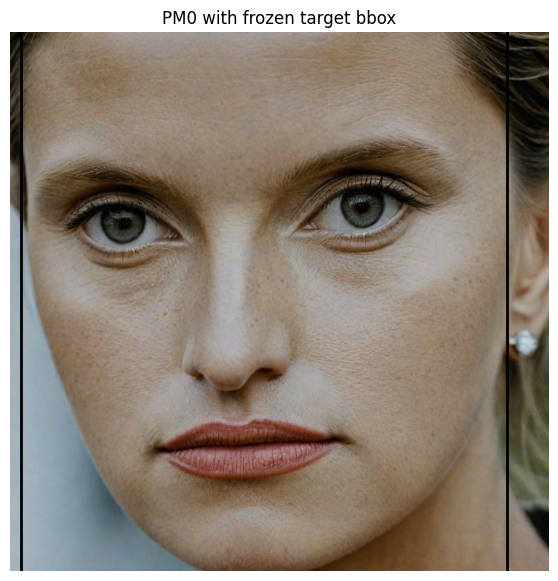

In [17]:
# ---------------------------
# PHOTOMAKER BASELINE
# ---------------------------
pm_result = run_generation(
    label="PM0",
    pm_identity_item=pm_item,
    spatial_reference_item=None,
    use_ba=False,
)

pm_image = pm_result["image"]
detected_bbox, pm_generated_embedding = detect_largest_face(pm_image)

target_bbox = (
    list(TARGET_BBOX_OVERRIDE)
    if TARGET_BBOX_OVERRIDE is not None
    else detected_bbox
)
if target_bbox is None:
    display(pm_image)
    raise RuntimeError(
        "No face was detected in PM0. Set TARGET_BBOX_OVERRIDE and rerun."
    )

print("Frozen target bbox:", target_bbox)
print("Saved:", pm_result["path"])

fig, axis = plt.subplots(figsize=(7, 7))
axis.imshow(pm_image)
x0, y0, x1, y1 = target_bbox
axis.add_patch(
    Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        fill=False,
        linewidth=2,
    )
)
axis.set_title("PM0 with frozen target bbox")
axis.axis("off")
plt.show()


## 7. Run the controlled full-pipeline matrix

The minimal matrix answers four questions:

| Condition | Question |
|---|---|
| `BA_off_A` | Does the doubled BA path reduce to PM when branch scale is zero? |
| `BA_current_A1` | Does the configured branch visibly alter PM? |
| `BA_current_A2` | Does a same-ID spatial-reference swap alter the output? |
| `BA_strong_A2` | Can this architecture alter the image when authority is deliberately high? |
| `BA_stress_no_anchor_A2` | Is the core/anchor hiding an otherwise active branch? |

The stress result is diagnostic only. Artifacts are acceptable there; an unchanged stress image is not.


In [18]:
# ---------------------------
# FULL PIPELINE MATRIX
# ---------------------------
current_alpha = float(processor_df["effective_gate"].median())
print("Current median effective gate:", current_alpha)

scenario_specs = [
    {
        "label": "BA_off_A1",
        "spatial_reference_item": spatial_item_a,
        "runtime_scale": 0.0,
    },
    {
        "label": "BA_current_A1",
        "spatial_reference_item": spatial_item_a,
        "runtime_scale": 1.0,
    },
    {
        "label": "BA_current_A2",
        "spatial_reference_item": spatial_item_b,
        "runtime_scale": 1.0,
    },
    {
        "label": "BA_strong_A2",
        "spatial_reference_item": spatial_item_b,
        "runtime_scale": 1.0,
        "effective_gate": 0.50,
        "gate_max_override": 1.0,
        "spatial_cap": 1.0,
        "total_cap": 1.0,
        "local_window": 15,
    },
]

if RUN_EXTENDED_STRESS_CASES:
    scenario_specs.extend(
        [
            {
                "label": "BA_stress_no_anchor_A2",
                "spatial_reference_item": spatial_item_b,
                "runtime_scale": 1.0,
                "effective_gate": 0.80,
                "gate_max_override": 1.0,
                "spatial_cap": 1.0,
                "total_cap": 1.0,
                "output_anchor": "none",
                "core_erode": 0.0,
                "local_window": 15,
            },
            {
                "label": "BA_shuffled_A2",
                "spatial_reference_item": spatial_item_b,
                "runtime_scale": 1.0,
                "effective_gate": 0.50,
                "gate_max_override": 1.0,
                "spatial_cap": 1.0,
                "total_cap": 1.0,
                "local_window": 15,
                "patch_transform": shuffled_patches,
            },
            {
                "label": "BA_zero_patches_A2",
                "spatial_reference_item": spatial_item_b,
                "runtime_scale": 1.0,
                "effective_gate": 0.50,
                "gate_max_override": 1.0,
                "spatial_cap": 1.0,
                "total_cap": 1.0,
                "local_window": 15,
                "patch_transform": zero_patches,
            },
        ]
    )

if wrong_item is not None:
    scenario_specs.append(
        {
            "label": "BA_strong_wrong_ID",
            "spatial_reference_item": wrong_item,
            "runtime_scale": 1.0,
            "effective_gate": 0.50,
            "gate_max_override": 1.0,
            "spatial_cap": 1.0,
            "total_cap": 1.0,
            "local_window": 15,
        }
    )

full_results = {"PM0": pm_result}
if RUN_FULL_PIPELINE_MATRIX:
    for specification in scenario_specs:
        print("\nRunning:", specification["label"])
        result = run_generation(
            pm_identity_item=pm_item,
            use_ba=True,
            target_bbox=target_bbox,
            **specification,
        )
        full_results[result["label"]] = result
        print("Saved:", result["path"])
        gc.collect()
        torch.cuda.empty_cache()
else:
    print("Full pipeline matrix disabled.")


Current median effective gate: 0.050231367349624634

Running: BA_off_A1
[AutoMaskRef] Using existing ref mask at None


  5%|▌         | 1/20 [00:00<00:02,  6.67it/s]

[Switch] step 0 → NO_ID  (photomaker_start_step=4, branched_attn_start_step=6)


 25%|██▌       | 5/20 [00:00<00:02,  6.48it/s]

[Switch] step 4 → PHOTOMAKER  (photomaker_start_step=4, branched_attn_start_step=6)


...

[Switch] step 6 → BOTH  (photomaker_start_step=4, branched_attn_start_step=6)


 35%|███▌      | 7/20 [00:01<00:05,  2.33it/s]

[BA output anchor] mode=base_outside_core state=base-outside-core core_mean=0.643138


100%|██████████| 20/20 [00:10<00:00,  1.83it/s]


Saved: /home/niko/rsrch/diffusion_template/debug_nn7_branch_notebook/20260722_191909_one_id_ba_NN7a_init/BA_strong_wrong_ID.png


In [19]:
# ---------------------------
# METRICS AND DIAGNOSTIC SUMMARY
# ---------------------------
reference_embeddings = {}
for key, item in (
    ("pm_identity_A", pm_item),
    ("same_id_A1", spatial_item_a),
    ("same_id_A2", spatial_item_b),
    ("wrong_id_B", wrong_item),
):
    if item is None:
        continue
    _, embedding = detect_largest_face(item.open())
    reference_embeddings[key] = embedding

summary_rows = []
for label, result in full_results.items():
    image = result["image"]
    generated_bbox, generated_embedding = detect_largest_face(image)
    full_mae, face_mae, outside_mae = mae_regions(
        image,
        pm_image,
        target_bbox,
    )

    processor_records = result["diagnostics"]["processor"]
    applied_ratios = [
        float(record["applied_ratio_p50"])
        for record in processor_records
        if record.get("record_type") == "processor_applied_ratio"
        and "applied_ratio_p50" in record
    ]
    gates = [
        float(record["gate"])
        for record in processor_records
        if record.get("record_type") == "processor_applied_ratio"
        and "gate" in record
    ]

    summary_rows.append(
        {
            "label": label,
            "face_detected": generated_bbox is not None,
            "full_mae_vs_PM": full_mae,
            "face_mae_vs_PM": face_mae,
            "outside_mae_vs_PM": outside_mae,
            "sim_to_PM_identity_A": cosine_np(
                generated_embedding,
                reference_embeddings.get("pm_identity_A"),
            ),
            "sim_to_same_ID_A1": cosine_np(
                generated_embedding,
                reference_embeddings.get("same_id_A1"),
            ),
            "sim_to_same_ID_A2": cosine_np(
                generated_embedding,
                reference_embeddings.get("same_id_A2"),
            ),
            "sim_to_wrong_ID_B": cosine_np(
                generated_embedding,
                reference_embeddings.get("wrong_id_B"),
            ),
            "processor_gate_mean": (
                float(np.mean(gates)) if gates else float("nan")
            ),
            "processor_applied_ratio_p50_mean": (
                float(np.mean(applied_ratios))
                if applied_ratios
                else float("nan")
            ),
            "path": str(result["path"]),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("label")
summary_path = OUTPUT_DIR / "summary.csv"
summary_df.to_csv(summary_path, index=False)
display(summary_df)
print("Saved summary:", summary_path)

# Same-ID reference-swap image difference.
if "BA_current_A1" in full_results and "BA_current_A2" in full_results:
    a = image_array(full_results["BA_current_A1"]["image"])
    b = image_array(full_results["BA_current_A2"]["image"])
    print(
        "Current same-ID A1/A2 output MAE:",
        float(np.abs(a - b).mean()),
    )


,label,face_detected,full_mae_vs_PM,face_mae_vs_PM,outside_mae_vs_PM,sim_to_PM_identity_A,sim_to_same_ID_A1,sim_to_same_ID_A2,sim_to_wrong_ID_B,processor_gate_mean,processor_applied_ratio_p50_mean,path
2,BA_current_A1,True,0.005140,0.005199,0.004599,0.515818,0.418031,0.455039,0.173394,0.050293,0.020608,/home/niko/rsrch/diffusion_template/debug_nn7_...
3,BA_current_A2,True,0.005031,0.005020,0.005139,0.518171,0.414832,0.450037,0.175028,0.050293,0.020623,/home/niko/rsrch/diffusion_template/debug_nn7_...
1,BA_off_A1,True,0.004041,0.004146,0.003066,0.515544,0.412821,0.447230,0.175914,0.050293,0.000000,/home/niko/rsrch/diffusion_template/debug_nn7_...
4,BA_strong_A2,True,0.029309,0.030909,0.014526,0.481575,0.378359,0.420705,0.173375,0.500000,0.456873,/home/niko/rsrch/diffusion_template/debug_nn7_...
5,BA_strong_wrong_ID,True,0.028959,0.030541,0.014341,0.449336,0.355361,0.382851,0.175766,0.500000,0.457082,/home/niko/rsrch/diffusion_template/debug_nn7_...
0,PM0,True,0.000000,0.000000,0.000000,0.511323,0.406792,0.444991,0.180284,NaN,NaN,/home/niko/rsrch/diffusion_template/debug_nn7_...


Saved summary: /home/niko/rsrch/diffusion_template/debug_nn7_branch_notebook/20260722_191909_one_id_ba_NN7a_init/summary.csv
Current same-ID A1/A2 output MAE: 0.003878160612657666


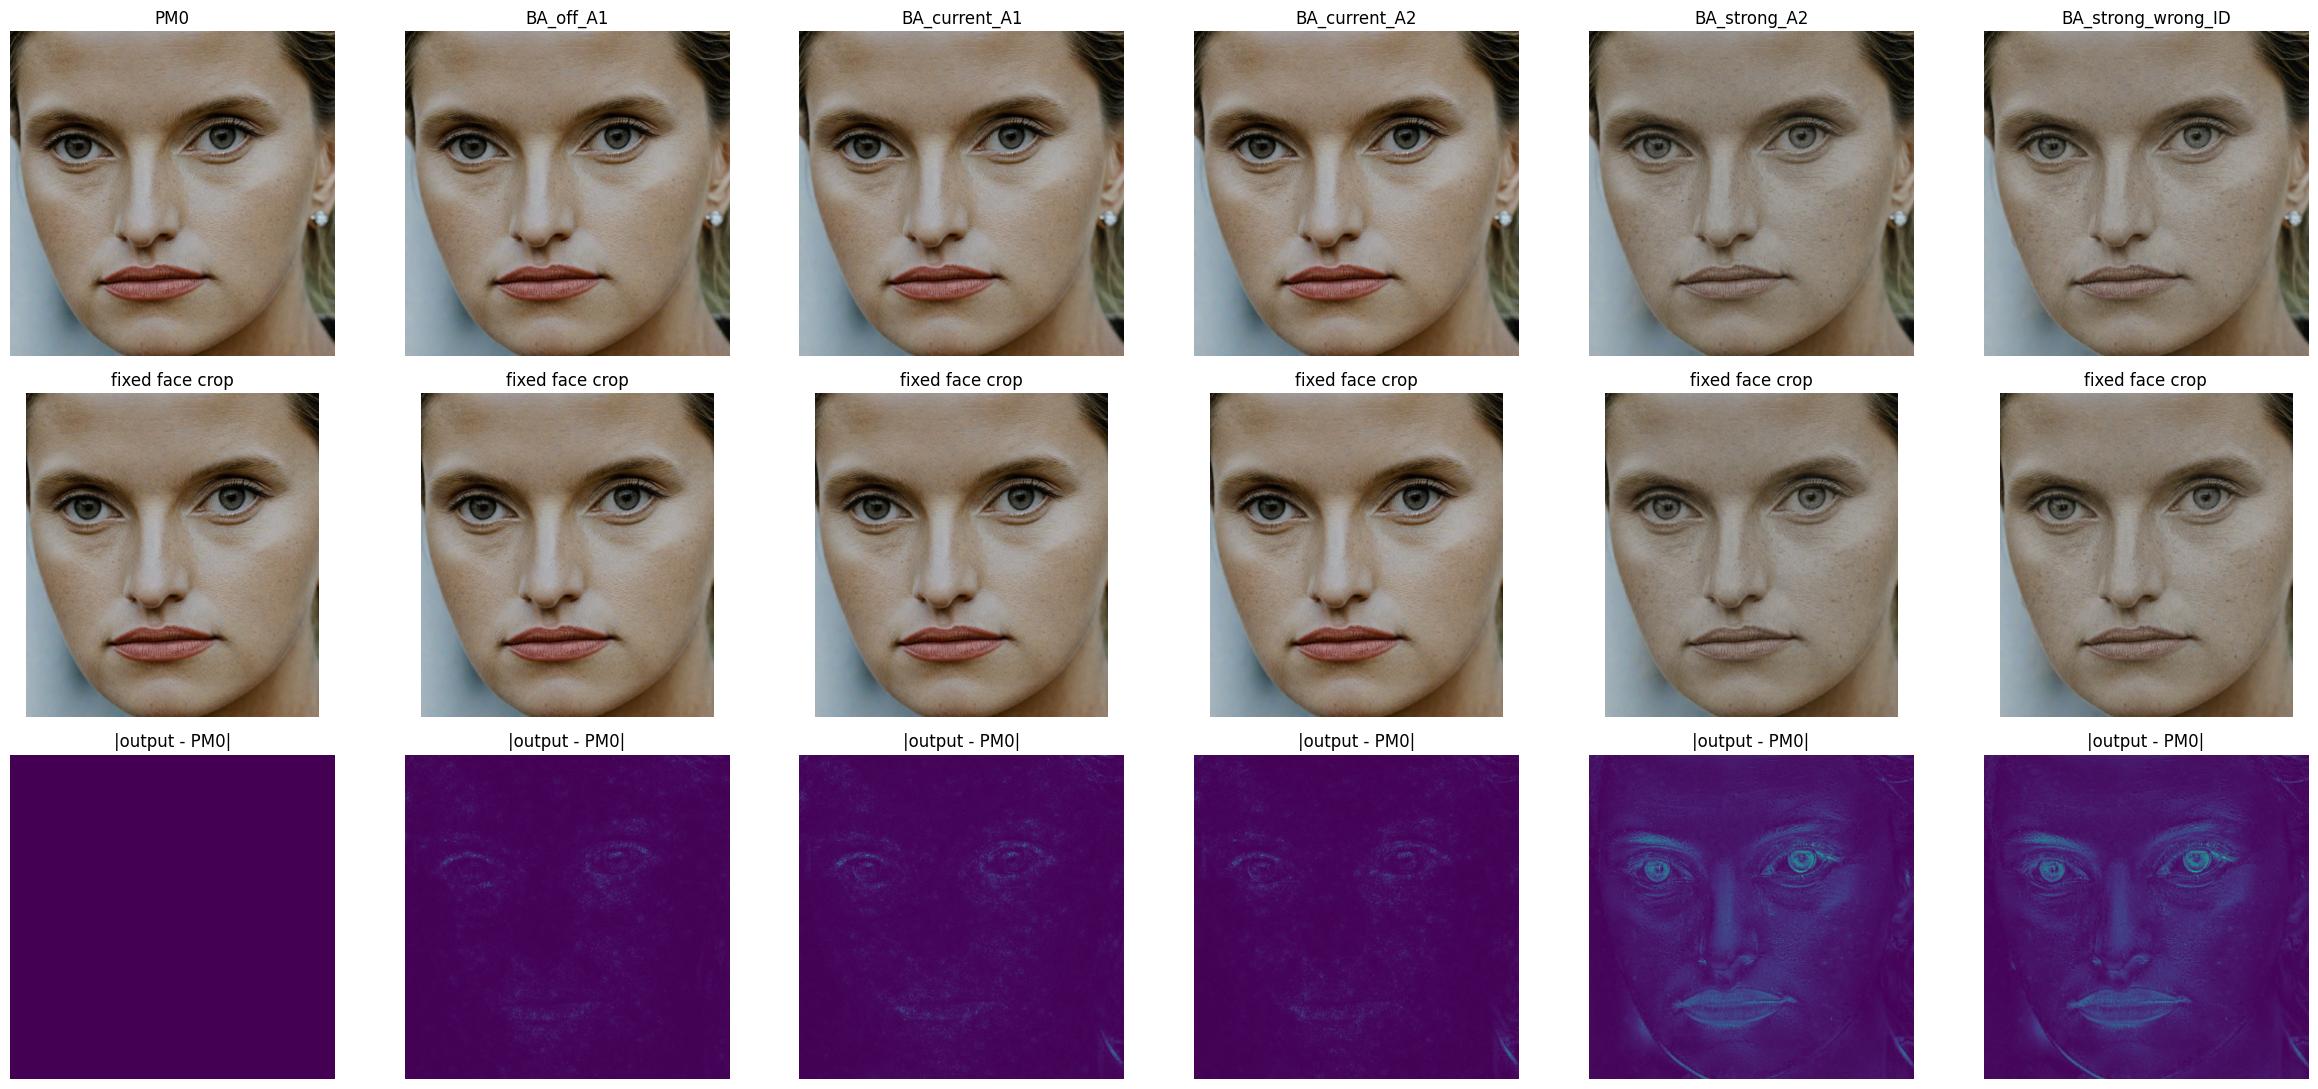

Saved grid: /home/niko/rsrch/diffusion_template/debug_nn7_branch_notebook/20260722_191909_one_id_ba_NN7a_init/comparison_grid.png


In [20]:
# ---------------------------
# IMAGE GRID, FACE CROPS AND DIFFERENCE MAPS
# ---------------------------
labels = list(full_results)
columns = len(labels)

fig, axes = plt.subplots(3, columns, figsize=(4 * columns, 11))
if columns == 1:
    axes = np.asarray(axes).reshape(3, 1)

baseline_array = image_array(pm_image)

for column, label in enumerate(labels):
    image = full_results[label]["image"]
    axes[0, column].imshow(image)
    axes[0, column].set_title(label)
    axes[0, column].axis("off")

    face_crop = crop_by_bbox(image, target_bbox)
    axes[1, column].imshow(face_crop)
    axes[1, column].set_title("fixed face crop")
    axes[1, column].axis("off")

    difference = np.abs(image_array(image) - baseline_array).mean(axis=2)
    axes[2, column].imshow(difference)
    axes[2, column].set_title("|output - PM0|")
    axes[2, column].axis("off")

plt.tight_layout()
grid_path = OUTPUT_DIR / "comparison_grid.png"
fig.savefig(grid_path, dpi=140, bbox_inches="tight")
plt.show()
print("Saved grid:", grid_path)


## 8. Interpretation

Use the first matching case.

### A. Patch-token test fails

```text
hash(A1) == hash(A2)
or
RMS(A1 - A2) == 0
```

**Cause:** reference selection/cropping/token extraction.  
Do not debug the U-Net yet.

---

### B. Patch tokens differ, but processor microprobe A1/A2 is zero even at high authority

**Cause:** processor reference candidate is insensitive to its memory, or the wrong processor/tokens are wired.

Inspect:

```text
processor.spatial_patch_tokens
ref_to_k / ref_to_v
local reference indices
spatial_has_roi
target core support
```

---

### C. Processor microprobe differs, but `BA_strong_A2` is visually and numerically identical to PM

**Cause:** full-pipeline routing problem.

Inspect:

```text
branched processors attached during BA steps
ppr_reference_image reaches clean patch extraction
processor applied-ratio diagnostics
target epsilon pre-anchor versus PM
scheduler receives branched epsilon
```

The deliberate strong condition should not remain unchanged.

---

### D. `BA_strong_A2` changes, but `BA_current_A1/A2` stay near PM

**Cause:** the current branch authority is too low or is washed out downstream.

This is the expected diagnosis when:

```text
current processor applied ratio is tiny
strong condition is clearly different
same-ID A1/A2 difference grows with authority
```

Then tune authority/scheduling rather than reference wiring.

---

### E. Only `BA_stress_no_anchor_A2` changes

**Cause:** target core or output anchor suppresses the effect.

Compare:

```text
ba_target_core_erode_frac
face_bbox_gen
core mask area
inside-core epsilon ratio
```

---

### F. Wrong-ID reference changes the output, but same-ID A1/A2 does not

The branch is reference-sensitive, but same-ID views are too similar in the chosen representation—or the desired same-ID pose invariance is already high.

Use wrong-ID A/B for causal identity debugging, and same-ID A1/A2 for pose/appearance invariance.

---

### G. Matched BA looks like PM, but A1/A2 or A/wrong-ID swaps differ

This is not a dead branch. PhotoMaker identity A and matched reference identity A agree.

The correct success test is:

```text
change only the spatial reference
→ output identity changes in that direction
```

not simply:

```text
matched BA must look far from PM
```

---

## Recommended testing sequence

1. Run `FAST_MODE=True`, no checkpoint.
2. Require a nonzero patch-memory difference.
3. Require a nonzero processor A1/A2 difference.
4. Run the minimal full matrix.
5. If `BA_strong_A2` changes, add the extended stress cases.
6. Repeat with:
   - `CONFIG_NAME="one_id_ba_NN7a_init_v2"`;
   - the 2k checkpoint;
   - the 4k checkpoint.
7. For any promising case, set `FAST_MODE=False` and rerun with the exact 50-step validation schedule.

Always restart the kernel before switching config or checkpoint.


In [21]:
# ---------------------------
# OPTIONAL: PRINT RAW DIAGNOSTICS FOR ONE CONDITION
# ---------------------------
DIAGNOSTIC_LABEL = (
    "BA_current_A2"
    if "BA_current_A2" in full_results
    else next(iter(full_results))
)

diagnostic_result = full_results[DIAGNOSTIC_LABEL]
print("Condition:", DIAGNOSTIC_LABEL)

print("\nFingerprints:")
print(json.dumps(
    diagnostic_result["diagnostics"]["fingerprints"],
    indent=2,
    default=str,
)[:12000])

print("\nProcessor records:")
for record in diagnostic_result["diagnostics"]["processor"][:20]:
    print(json.dumps(record, indent=2, default=str)[:4000])

print("\nEpsilon records:")
for record in diagnostic_result["diagnostics"]["epsilon"][:20]:
    print(json.dumps(record, indent=2, default=str)[:4000])


Condition: BA_current_A2

Fingerprints:
{
  "initial_latents_sha256": [
    "287143c3d998c2ab95fd7687499a3e45e01984b5ea5ce0f7ea9a4830ec14de91"
  ],
  "target_prompt_embeds_sha256": [
    "bf743f0189aac2a975faeb2978525bbeca5fb27dde7871904c7df37371b5f794"
  ],
  "reference_latents_sha256": [
    "0a4f26669ce8213ebff961e188a28a0335bc512079ca5dc10c356223f62f894d"
  ],
  "reference_noise_sha256": [
    "dd94ba9ff56a864199f5775f730f3aee68bb5c356f74b62134291b8a2d2bc496"
  ],
  "reference_mask_nonempty": [
    true
  ],
  "reference_mask_sha256": [
    "f7a0c097b0362e01241dfc9b92730c4c9cabbcaec564a546193f9300ba5fddad"
  ],
  "target_photomaker_id_embeds_sha256": [
    "020115b35a950f56b780371851ee79a12cdb1cc0796814e22a4f95d848ac7bf4"
  ],
  "clean_spatial_patch_tokens_sha256": [
    "fc95c0a63cda6d19850f560a9e0b6735ad330f05fb5a50f8f9463d91c5d09683"
  ],
  "cfg_reference_noise_equal": true,
  "cfg_ref_noised_equal": true,
  "reference_noise_used_sha256": [
    "dd94ba9ff56a864199f5775f730f3aee6

## 9. Cleanup

Run this before rebuilding another architecture in the same kernel. A full kernel restart is still safer.


In [22]:
# Optional cleanup.
# Uncomment after saving all outputs and before rebuilding another config.

# del pipe, model, cfg, accelerator
# gc.collect()
# torch.cuda.empty_cache()
# print("CUDA cache cleared. Restart the kernel before a new architecture when possible.")
